In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('Retail_Transactions_Dataset.csv')

# Tampilkan 5 data awal
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [ ]:
df.tail()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
996379,1000996379,2020-02-27 16:14:56,Seth Gonzales,"['Bath Towels', 'Cereal']",1,29.31,Credit Card,Houston,Pharmacy,True,Young Adult,Spring,NaN
996380,1000996380,2023-08-01 20:50:51,Jacqueline Murray DDS,"['Hand Sanitizer', 'Pancake Mix', 'Air Freshen...",1,93.82,Cash,Dallas,Warehouse Club,False,Professional,Winter,NaN
996381,1000996381,2024-02-04 13:00:35,Mary Richards,"['Lawn Mower', 'Pickles', 'Broom', 'Bread']",4,7.59,Cash,Chicago,Specialty Store,True,Retiree,Fall,BOGO (Buy One Get One)
996382,1000996382,2022-10-22 01:19:55,Sean Barker,['Paper Towels'],8,60.33,Mobile Payment,Miami,Department Store,False,Homemaker,Fall,NaN
996383,1000996383,2020-03-27 07:26:35,Rebekah Clark,"['Toothpaste', 'Ironing Board', 'Cleaning Spra...",3,89.28,Cash,Chicago,Warehouse Club,True,Middle-Ag,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          666057 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB


**PREPROCESSING**

In [ ]:
# Ubah ke tipe datetime
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df = df[df['Date'].dt.year.isin([2022, 2023, 2024])]

In [ ]:
# Tampilkan 5 data awal
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
6,1000000006,2023-01-08 10:40:03,Victoria Garrett,"['Honey', 'BBQ Sauce', 'Soda', 'Olive Oil', 'G...",4,5.28,Cash,Boston,Specialty Store,False,Student,Summer,Discount on Selected Items
11,1000000011,2023-03-30 19:26:41,Jeremiah White,"['Tea', 'Paper Towels', 'Spinach']",7,31.88,Mobile Payment,New York,Specialty Store,False,Young Adult,Fall,Discount on Selected Items


In [ ]:
import ast

# Pastikan format list
df['Product'] = df['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Date'].dt.hour
df['Weekday'] = df['Date'].dt.day_name()

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Customer_Name,0
Product,0
Total_Items,0
Total_Cost,0
Payment_Method,0
City,0
Store_Type,0
Discount_Applied,0


In [ ]:
# Daftar kolom dengan 1 missing value
cols_with_1_missing = ['Payment_Method', 'City', 'Store_Type',
                       'Discount_Applied', 'Customer_Category', 'Season']

for col in cols_with_1_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df['Promotion'].fillna('No Promotion', inplace=True)

/tmp/ipython-input-10-2923243387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Promotion'].fillna('No Promotion', inplace=True)


**EDA**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='whitegrid')

/tmp/ipython-input-66-383494329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Payment_Method', palette='pastel')


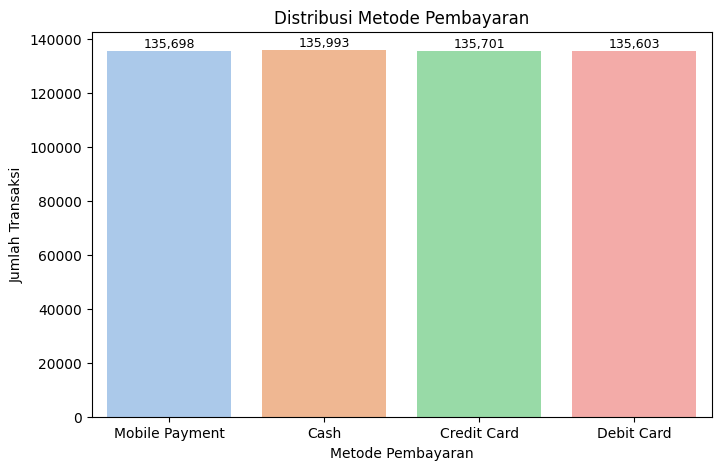

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Payment_Method', palette='pastel')
plt.title('Distribusi Metode Pembayaran')

# Tambah label di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5), textcoords='offset points')

plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.show()

/tmp/ipython-input-67-3789317486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cities.index, x=top_cities.values, palette='mako')


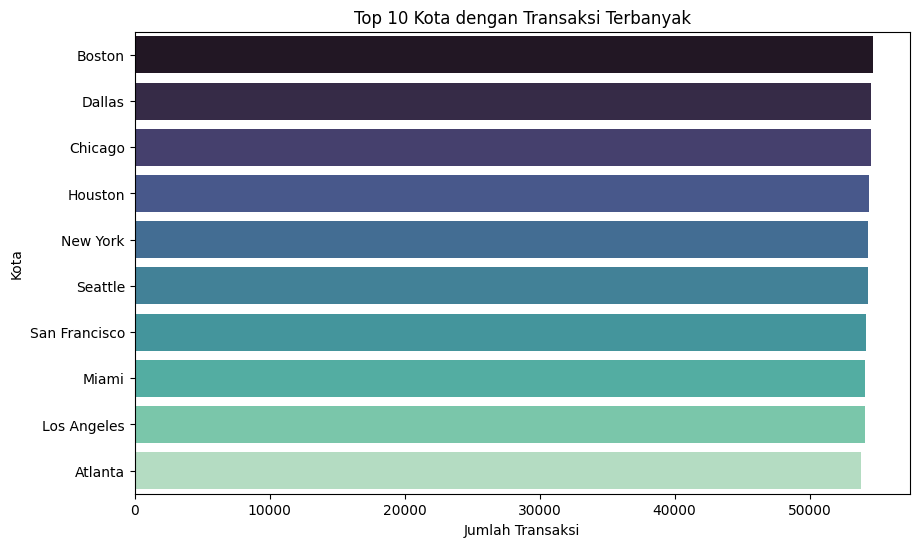

In [ ]:
plt.figure(figsize=(10,6))
top_cities = df['City'].value_counts().nlargest(10)
sns.barplot(y=top_cities.index, x=top_cities.values, palette='mako')
plt.title('Top 10 Kota dengan Transaksi Terbanyak')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Kota')
plt.show()

/tmp/ipython-input-68-1314103981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Month', y='Total_Cost', palette='viridis')


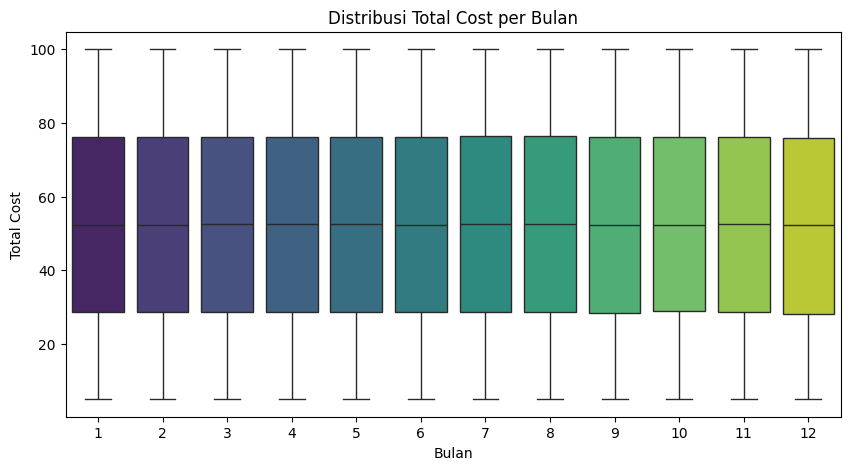

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Month', y='Total_Cost', palette='viridis')
plt.title('Distribusi Total Cost per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Cost')
plt.show()

/tmp/ipython-input-70-1357959794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Store_Type', y='Total_Items', palette='Set2')


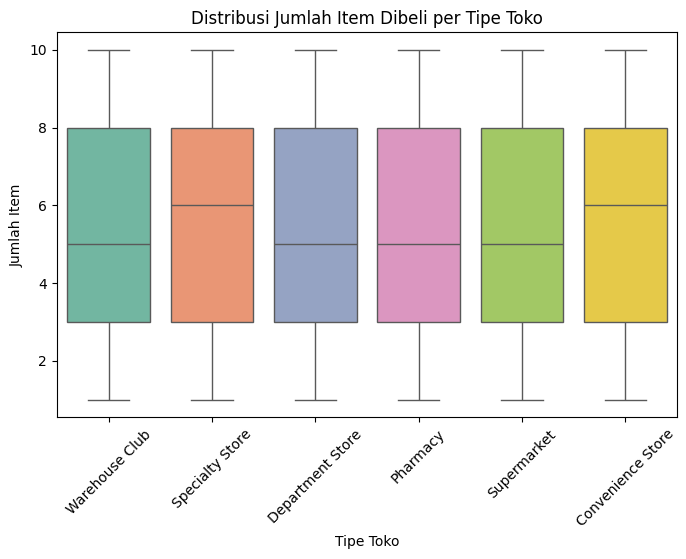

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Store_Type', y='Total_Items', palette='Set2')
plt.title('Distribusi Jumlah Item Dibeli per Tipe Toko')
plt.xticks(rotation=45)
plt.xlabel('Tipe Toko')
plt.ylabel('Jumlah Item')
plt.show()

/tmp/ipython-input-71-3473304457.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Discount_Applied', palette='coolwarm')


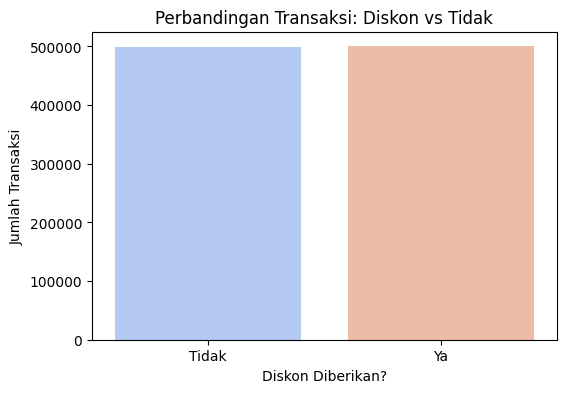

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Discount_Applied', palette='coolwarm')
plt.title('Perbandingan Transaksi: Diskon vs Tidak')
plt.xlabel('Diskon Diberikan?')
plt.ylabel('Jumlah Transaksi')
plt.xticks([0,1], ['Tidak', 'Ya'])
plt.show()

/tmp/ipython-input-72-2238730387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Promotion', order=df['Promotion'].value_counts().index, palette='pastel')


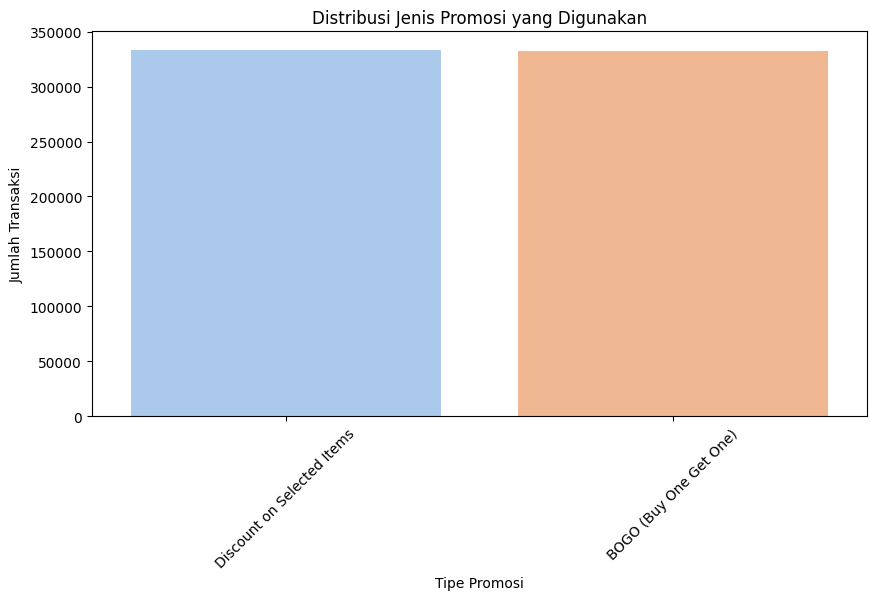

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Promotion', order=df['Promotion'].value_counts().index, palette='pastel')
plt.title('Distribusi Jenis Promosi yang Digunakan')
plt.xticks(rotation=45)
plt.xlabel('Tipe Promosi')
plt.ylabel('Jumlah Transaksi')
plt.show()

/tmp/ipython-input-73-4025267631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Customer_Category', palette='Set3')


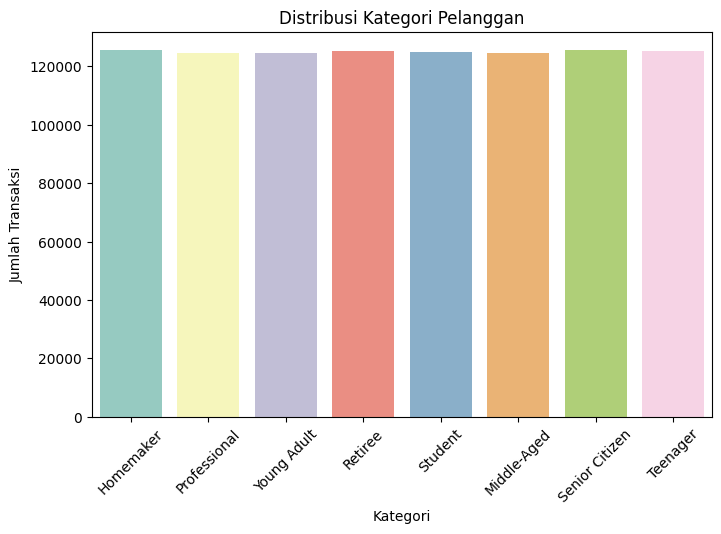

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Customer_Category', palette='Set3')
plt.title('Distribusi Kategori Pelanggan')
plt.xticks(rotation=45)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Transaksi')
plt.show()

/tmp/ipython-input-74-4234675890.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=products, palette='Blues_r')


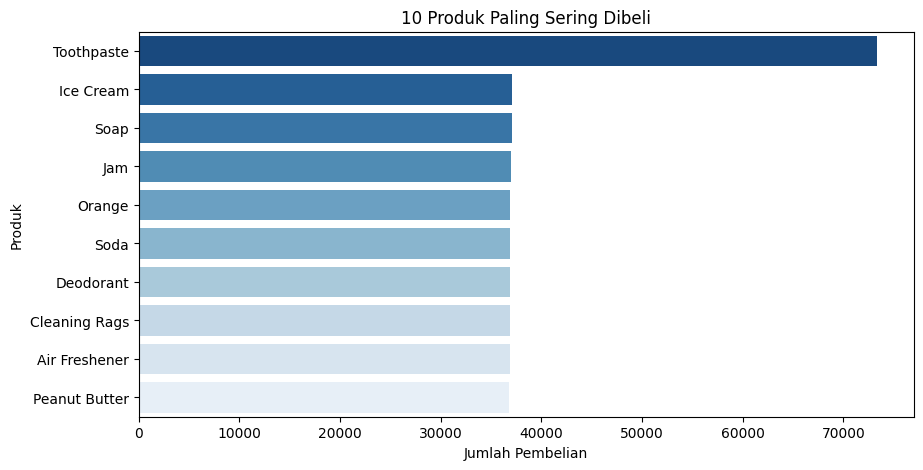

In [ ]:
from collections import Counter

# Pastikan kolom 'Product' sudah dalam format list
import ast
df['Product'] = df['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

all_products = [item for sublist in df['Product'] for item in sublist]
top_products = Counter(all_products).most_common(10)

products, counts = zip(*top_products)
plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=products, palette='Blues_r')
plt.title('10 Produk Paling Sering Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Produk')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Weekday', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='flare')
plt.title('Jumlah Transaksi per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `Weekday` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Hour'], bins=24, kde=False, color='coral')
plt.title('Distribusi Jam Transaksi')
plt.xlabel('Jam')
plt.ylabel('Jumlah Transaksi')
plt.xticks(range(0, 24))
plt.show()

**ASSOCIATION**

In [ ]:
import pandas as pd
import ast
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [ ]:
# Ubah kolom Product ke list
df['Product'] = df['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Filter hanya transaksi dengan ≥ 2 produk
df_filtered = df[df['Product'].apply(len) > 1].copy()

# Simpan sebagai list of list
transactions = df_filtered['Product'].tolist()

print(f"Jumlah transaksi dengan ≥2 produk: {len(transactions)}")

Jumlah transaksi dengan ≥2 produk: 434391


In [ ]:
print(f"Jumlah transaksi: {len(df_filtered)}")

Jumlah transaksi: 434391


In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Jumlah kolom produk unik: {df_encoded.shape[1]}")

Jumlah kolom produk unik: 81


In [ ]:
frequent_itemsets = fpgrowth(df_encoded, min_support=0.002, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Cek panjang kombinasi itemset
print(frequent_itemsets['length'].value_counts())

length
1    81
2    80
Name: count, dtype: int64


In [ ]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.07)

print(f"Jumlah rules terbentuk: {len(rules)}")

Jumlah rules terbentuk: 16


In [ ]:
rules['lift'].describe()
rules['confidence'].describe()

,confidence
count,16.000000
mean,0.071299
std,0.001024
min,0.070036
25%,0.070460
50%,0.071127
75%,0.071758
max,0.073517


In [ ]:
# Fungsi bantu untuk pisahkan antecedents
def extract_items(itemset):
    items = list(itemset)
    if len(items) == 1:
        return items[0], ''
    elif len(items) >= 2:
        return items[0], items[1]
    return '', ''

# Gabungkan seluruh antecedents jadi 1 string kolom
rules['Antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['Consequent'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Format nilai numerik jadi persen & lift
rules['Support %'] = (rules['support'] * 100).round(2)
rules['Confidence %'] = (rules['confidence'] * 100).round(2)
rules['Rule Support %'] = rules['Support %']
rules['Lift'] = rules['lift'].round(2)

In [ ]:
final_rules = rules[['Antecedents', 'Consequent',
                     'Support %', 'Confidence %', 'Rule Support %', 'Lift']]

# Tampilkan top 10 rule dengan lift tertinggi
final_rules.sort_values(by='Lift', ascending=False).head(17)

,Antecedents,Consequent,Support %,Confidence %,Rule Support %,Lift
2,Apple,Toothpaste,0.31,7.35,0.31,0.89
10,Baby Wipes,Toothpaste,0.31,7.29,0.31,0.88
7,Cheese,Toothpaste,0.30,7.21,0.30,0.87
1,Olive Oil,Toothpaste,0.30,7.24,0.30,0.87
9,Toilet Paper,Toothpaste,0.30,7.16,0.30,0.87
11,Trash Cans,Toothpaste,0.30,7.16,0.30,0.87
4,Yogurt,Toothpaste,0.30,7.11,0.30,0.86
0,Ketchup,Toothpaste,0.30,7.09,0.30,0.86
14,Deodorant,Toothpaste,0.30,7.12,0.30,0.86
8,Cleaning Spray,Toothpaste,0.30,7.15,0.30,0.86


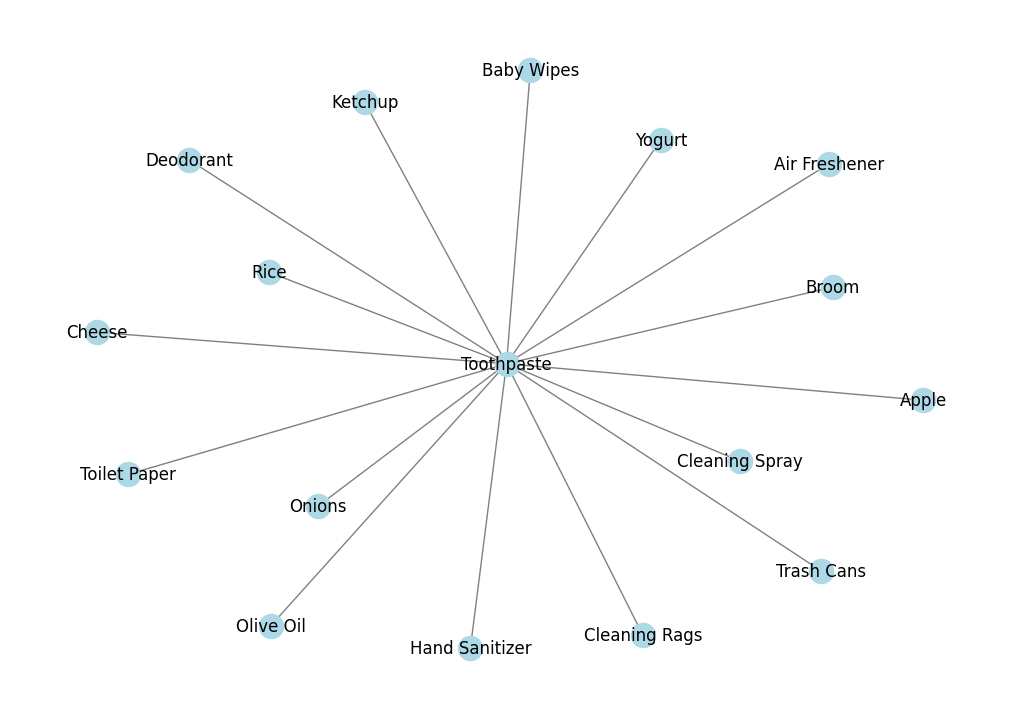

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(final_rules.head(20),
                            source='Antecedents',
                            target='Consequent',
                            edge_attr=True)
plt.figure(figsize=(10,7))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')

**CUSTOMER PROFILING**

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Pastikan tidak ada nilai kosong
profil_cols = ['Payment_Method',
               'Customer_Category', 'Promotion', 'Season', 'Discount_Applied', 'Store_Type']

# Isi missing value (jika belum dilakukan sebelumnya)
for col in profil_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df_profil = df[['Transaction_ID'] + profil_cols].drop_duplicates(subset='Transaction_ID')
df_profil.set_index('Transaction_ID', inplace=True)

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df_profil)

# Konversi ke DataFrame
encoded_df = pd.DataFrame(encoded_data,
                          index=df_profil.index,
                          columns=encoder.get_feature_names_out(profil_cols))

In [ ]:
# Tampilkan 5 baris pertama hasil encoding
encoded_df.tail()

,Payment_Method_Cash,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Mobile Payment,Customer_Category_Homemaker,Customer_Category_Middle-Aged,Customer_Category_Professional,Customer_Category_Retiree,Customer_Category_Senior Citizen,Customer_Category_Student,...,Season_Summer,Season_Winter,Discount_Applied_False,Discount_Applied_True,Store_Type_Convenience Store,Store_Type_Department Store,Store_Type_Pharmacy,Store_Type_Specialty Store,Store_Type_Supermarket,Store_Type_Warehouse Club
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
1000999992,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1000999993,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1000999995,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1000999996,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1000999998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


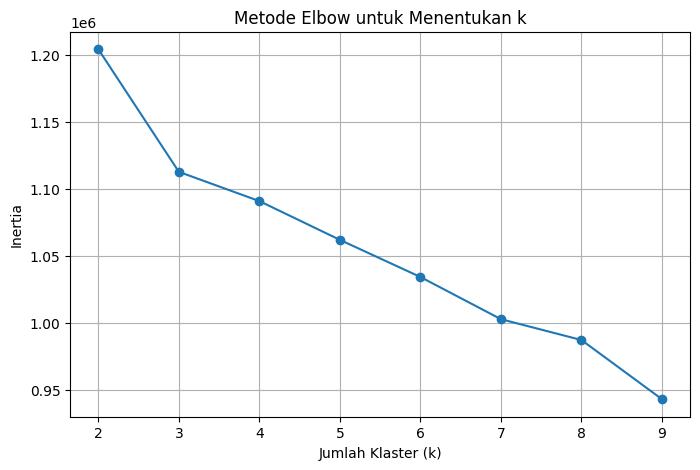

In [ ]:
inertia = []
K = range(2, 10)  # Coba 2 sampai 9 klaster

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(encoded_df)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'o-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans

# Kolom-kolom demografis untuk clustering
profil_cols = ['Payment_Method', 'Customer_Category', 'Promotion', 'Season', 'Discount_Applied', 'Store_Type']

# One-hot encoding untuk variabel kategorikal
encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[profil_cols]).toarray()

# Menentukan jumlah cluster berdasarkan elbow (misal k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(encoded)

In [ ]:
import pandas as pd

# 1. Hitung jumlah anggota tiap cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

# 2. Hitung persentase anggota tiap cluster
cluster_percentage = (cluster_counts / cluster_counts.sum() * 100).round(2)

# 3. Hitung rata-rata total transaksi (Total_Cost) per cluster
cluster_avg_transaction = df.groupby('Cluster')['Total_Cost'].mean().round(2)

# 4. Gabungkan semuanya ke dalam DataFrame
summary_df = pd.DataFrame({
    'Cluster Member': cluster_counts,
    'Percentage (%)': cluster_percentage,
    'Total Transaction (Rp)': cluster_avg_transaction
}).reset_index().rename(columns={'index': 'Cluster'})

# 5. Tampilkan
summary_df

,Cluster,Cluster Member,Percentage (%),Total Transaction (Rp)
0,0,333625,33.36,52.48
1,1,332687,33.27,52.42
2,2,333688,33.37,52.47


In [ ]:
# Ringkasan mode value tiap kolom per cluster
cluster_summary = df.groupby('Cluster')[profil_cols].agg(lambda x: x.value_counts().index[0])
cluster_summary

,Payment_Method,Customer_Category,Promotion,Season,Discount_Applied,Store_Type
Cluster,,,,,,
0,Credit Card,Retiree,Discount on Selected Items,Spring,True,Pharmacy
1,Cash,Teenager,BOGO (Buy One Get One),Spring,True,Supermarket
2,Mobile Payment,Professional,Discount on Selected Items,Fall,False,Supermarket


In [ ]:
# Pastikan kolom 'Product' dalam bentuk list (jika sebelumnya string)
import ast
df['Product'] = df['Product'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
from collections import Counter
import pandas as pd

rule_cluster_result = []

# 1. Loop setiap aturan asosiasi (pakai kolom yang sudah diubah ke string)
for idx, row in rules.iterrows():
    antecedents_list = row['Antecedents'].split(', ')

    # 2. Cari transaksi yang mengandung produk di antecedents
    matched = df[df['Product'].apply(lambda x: any(item in x for item in antecedents_list))]

    # 3. Hitung distribusi cluster
    cluster_counts = Counter(matched['Cluster'])

    if cluster_counts:
        dominant_cluster = cluster_counts.most_common(1)[0][0]
        dominance_pct = round((cluster_counts[dominant_cluster] / sum(cluster_counts.values())) * 100, 2)
        total = sum(cluster_counts.values())
    else:
        dominant_cluster, dominance_pct, total = None, 0, 0

    # 4. Simpan hasil
    rule_cluster_result.append({
        'Antecedent': row['Antecedents'],
        'Consequent': row['Consequent'],
        'Support': round(row['support'],6),
        'Confidence': round(row['confidence'],4),
        'Lift': round(row['lift'],4),
        'Dominant_Cluster': dominant_cluster,
        'Cluster_Dominance (%)': dominance_pct,
        'Total_Matched_Transactions': total
    })

# 5. Buat DataFrame hasil
df_rule_cluster = pd.DataFrame(rule_cluster_result)

# 6. Filter hanya Cluster 0, 1, 2
filtered_df = df_rule_cluster[df_rule_cluster['Dominant_Cluster'].isin([0, 1, 2])].copy()

# 7. Ambil 1 aturan terbaik (Lift tertinggi) untuk tiap Cluster 0, 1, 2 → selalu tampil
final_rules_list = []

for cluster_id in [0, 1, 2]:
    cluster_rules = filtered_df[filtered_df['Dominant_Cluster'] == cluster_id]
    if not cluster_rules.empty:
        top_rule = cluster_rules.sort_values(by='Lift', ascending=False).head(1)
        final_rules_list.append(top_rule)
    else:
        # Tetap tampil meskipun kosong
        empty_row = pd.DataFrame({
            'Antecedent': ['-'],
            'Consequent': ['-'],
            'Support': [0],
            'Confidence': [0],
            'Lift': [0],
            'Dominant_Cluster': [cluster_id],
            'Cluster_Dominance (%)': [0],
            'Total_Matched_Transactions': [0]
        })
        final_rules_list.append(empty_row)

# 8. Gabungkan semua hasil
final_rules = pd.concat(final_rules_list, ignore_index=True)

# 9. Tampilkan
final_rules

,Antecedent,Consequent,Support,Confidence,Lift,Dominant_Cluster,Cluster_Dominance (%),Total_Matched_Transactions
0,Apple,Toothpaste,0.003062,0.0735,0.8884,0,33.71,35748
1,Cleaning Spray,Toothpaste,0.002988,0.0715,0.8644,1,33.47,36185
2,Cheese,Toothpaste,0.003041,0.0721,0.8715,2,33.65,35975


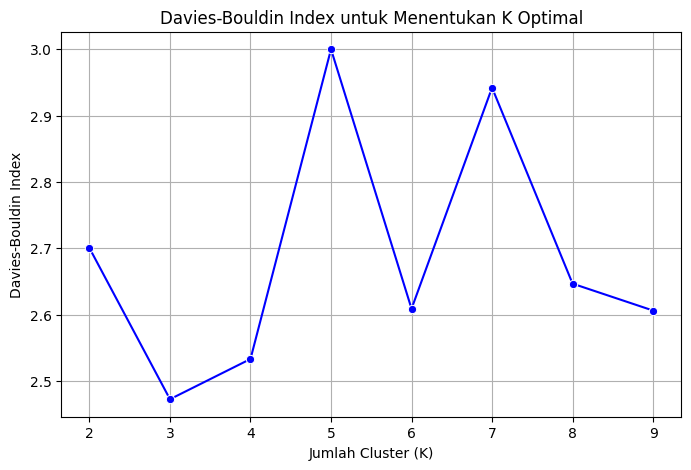

Jumlah Cluster 2: Davies-Bouldin Index = 2.7003
Jumlah Cluster 3: Davies-Bouldin Index = 2.4724
Jumlah Cluster 4: Davies-Bouldin Index = 2.5331
Jumlah Cluster 5: Davies-Bouldin Index = 3.0
Jumlah Cluster 6: Davies-Bouldin Index = 2.6088
Jumlah Cluster 7: Davies-Bouldin Index = 2.942
Jumlah Cluster 8: Davies-Bouldin Index = 2.6467
Jumlah Cluster 9: Davies-Bouldin Index = 2.6061


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('Retail_Transactions_Dataset.csv')

# 2. Pilih kolom-kolom untuk profiling (ganti sesuai kebutuhan)
profil_cols = ['Payment_Method', 'Customer_Category', 'Promotion', 'Season', 'Discount_Applied', 'Store_Type']

# 3. Isi missing value (jika ada)
for col in profil_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[profil_cols])

# 5. Optional: Standarisasi (bisa diskip karena ini data kategorikal)
# scaler = StandardScaler()
# encoded_data = scaler.fit_transform(encoded_data)

# 6. Simpan hasil DBI untuk berbagai k
dbi_scores = []
range_n_clusters = range(2, 10)

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(encoded_data)

    # Hitung Davies-Bouldin Index
    dbi = davies_bouldin_score(encoded_data, cluster_labels)
    dbi_scores.append(dbi)

# 7. Visualisasi DBI
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(range_n_clusters), y=dbi_scores, marker='o', color='blue')
plt.title('Davies-Bouldin Index untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True)
plt.show()

# 8. Tampilkan skor DBI tiap k
for k, score in zip(range_n_clusters, dbi_scores):
    print(f'Jumlah Cluster {k}: Davies-Bouldin Index = {round(score, 4)}')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df_rule_cluster, x='Dominant_Cluster', y='Cluster_Dominance (%)')
plt.title('Dominasi Cluster terhadap Asosiasi Produk')
plt.show()